# Prediction robustness

This notebook audits the alternative targets created by `scripts/26_build_robustness_targets.py` and the model results created by `scripts/27_build_prediction_robustness.py`.

It examines:

1. completeness and usability of the 21- and 126-day drawdown targets;
2. held-out performance across four prespecified downside-risk outcomes; and
3. monotonic realized risk across prediction deciles.

The notebook reads saved outputs only. It does not rebuild targets, refit models, or change the primary specification.

## 1. Fixed design

The feature set, preprocessing, hyperparameters, chronological splits, and held-out test period are unchanged. The four pre-specified outcomes are 63-day downside volatility, positive 63-day worst-five-day loss, and maximum drawdown over 21 and 126 market days. Incomplete outcome windows and training or validation windows crossing a split boundary are excluded.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd


project_root = Path.cwd().resolve()
while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
robustness_directory = paths.tables / "robustness"
modeling_directory = paths.processed / "modeling"
files = {
    "modeling sample": modeling_directory / "modeling_sample.parquet",
    "alternative targets": modeling_directory / "robustness_targets.parquet",
    "performance": robustness_directory / "prediction_robustness_performance.csv",
    "predictions": robustness_directory / "prediction_robustness_test_predictions.parquet",
    "deciles": robustness_directory / "prediction_robustness_deciles.csv",
}

for description, path in files.items():
    if not path.is_file():
        raise FileNotFoundError(f"{description} not found: {path}")

In [2]:
sample = pd.read_parquet(
    files["modeling sample"],
    columns=["report_period", "information_date", "permno", "sample_split"],
)
targets = pd.read_parquet(files["alternative targets"])
performance = pd.read_csv(files["performance"])
predictions = pd.read_parquet(files["predictions"])
deciles = pd.read_csv(files["deciles"], parse_dates=["report_period"])

target_labels = {
    "future_downside_volatility_63d": "Downside volatility (63d)",
    "future_worst_five_day_loss_63d": "Worst five-day loss (63d)",
    "future_max_drawdown_21d": "Maximum drawdown (21d)",
    "future_max_drawdown_126d": "Maximum drawdown (126d)",
}
expected_horizons = {21, 126}
expected_targets = set(target_labels)
target_keys = ["report_period", "information_date", "permno", "horizon_market_days"]

if set(targets["horizon_market_days"]) != expected_horizons:
    raise RuntimeError("Unexpected robustness-target horizons.")
if len(targets) != len(sample) * len(expected_horizons):
    raise RuntimeError("Each modeling observation must have both target horizons.")
if targets.duplicated(target_keys).any():
    raise RuntimeError("Robustness-target keys are duplicated.")
if (targets["target_window_start"] <= targets["information_date"]).any():
    raise RuntimeError("A robustness window starts before its information date.")
if targets.loc[targets["target_usable"], "future_max_drawdown"].isna().any():
    raise RuntimeError("A usable robustness target has no realized drawdown.")
if set(performance["target"]) != expected_targets:
    raise RuntimeError("Unexpected prediction-robustness targets.")
if set(predictions["target"]) != expected_targets:
    raise RuntimeError("Prediction rows do not cover all robustness targets.")
if performance.isna().any().any() or predictions.isna().any().any() or deciles.isna().any().any():
    raise RuntimeError("Prediction-robustness outputs contain missing values.")
if predictions.duplicated(["target", "report_period", "permno"]).any():
    raise RuntimeError("Prediction-robustness keys are duplicated.")
if not predictions["score"].between(0, 100).all():
    raise RuntimeError("Robustness scores must be between 0 and 100.")
if not predictions["decile"].between(1, 10).all():
    raise RuntimeError("Robustness deciles must be between 1 and 10.")
if not deciles.groupby(["target", "report_period"])["decile"].nunique().eq(10).all():
    raise RuntimeError("Every evaluated target-quarter must contain ten deciles.")
prediction_counts = predictions.groupby("target").size()
expected_counts = performance.set_index("target")["test_observations"]
if not prediction_counts.equals(expected_counts.loc[prediction_counts.index]):
    raise RuntimeError("Prediction counts do not match the performance table.")

print(f"Alternative-target rows: {len(targets):,}")
print(f"Modeled robustness outcomes: {len(performance)}")
print(f"Test predictions: {len(predictions):,}")
print("Prediction-robustness audit: PASS")

Alternative-target rows: 368,036
Modeled robustness outcomes: 4
Test predictions: 118,311
Prediction-robustness audit: PASS


## 2. Alternative-target availability

Every stock-quarter receives a 21-day and a 126-day target candidate. A target is usable only when its forward market-day window is complete and the stock has sufficient return coverage, with observed delisting returns handled explicitly by Script 26.

,horizon_market_days,sample_split,observations,complete_windows,usable_targets,complete_share,usable_share
0,21,test,"30,511","30,511","30,509",100.00%,99.99%
1,21,train,"123,791","123,791","123,783",100.00%,99.99%
2,21,validation,"29,716","29,716","29,714",100.00%,99.99%
3,126,test,"30,511","26,845","26,819",87.98%,87.90%
4,126,train,"123,791","123,791","123,716",100.00%,99.94%
5,126,validation,"29,716","29,716","29,692",100.00%,99.92%


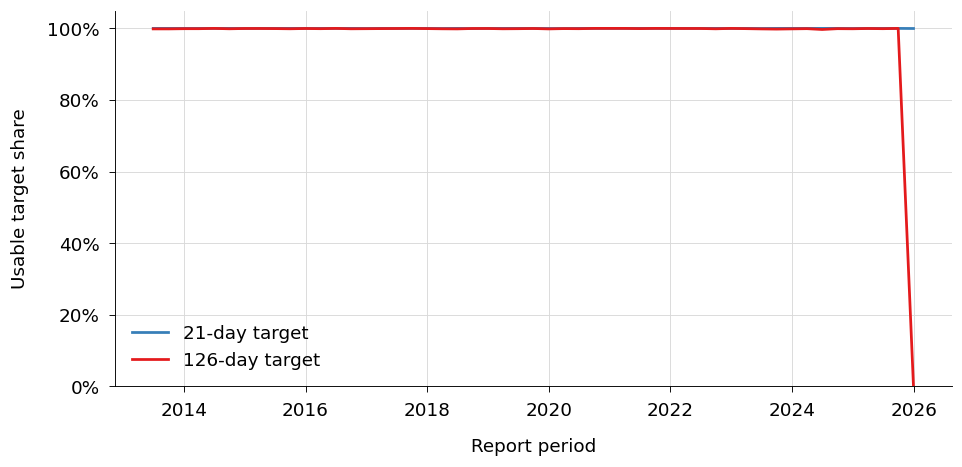

In [3]:
target_panel = targets.merge(
    sample,
    on=["report_period", "information_date", "permno"],
    how="left",
    validate="many_to_one",
)
target_summary = (
    target_panel.groupby(["horizon_market_days", "sample_split"], as_index=False)
    .agg(
        observations=("permno", "size"),
        complete_windows=("target_window_complete", "sum"),
        usable_targets=("target_usable", "sum"),
    )
)
target_summary["complete_share"] = (
    target_summary["complete_windows"] / target_summary["observations"]
)
target_summary["usable_share"] = (
    target_summary["usable_targets"] / target_summary["observations"]
)
display(
    target_summary.style.format(
        {
            "observations": "{:,.0f}",
            "complete_windows": "{:,.0f}",
            "usable_targets": "{:,.0f}",
            "complete_share": "{:.2%}",
            "usable_share": "{:.2%}",
        }
    )
)

quarterly_availability = (
    target_panel.groupby(["report_period", "horizon_market_days"], as_index=False)
    .agg(usable_share=("target_usable", "mean"))
)
fig, ax = plt.subplots(figsize=(9, 4.5))
for horizon, rows in quarterly_availability.groupby("horizon_market_days"):
    ax.plot(
        rows["report_period"],
        rows["usable_share"],
        label=f"{horizon}-day target",
    )
ax.set(
    xlabel="Report period",
    ylabel="Usable target share",
)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "06_01_alternative_target_availability.pdf")
plt.show()

## 3. Out-of-sample performance

In [4]:
summary = performance.copy()
summary["Outcome"] = summary["target"].map(target_labels)
display(
    summary[
        [
            "Outcome",
            "test_observations",
            "test_quarters",
            "mae",
            "rmse",
            "r2",
            "mean_quarterly_spearman",
            "mean_decile_spearman",
        ]
    ].style.format(
        {
            "test_observations": "{:,.0f}",
            "test_quarters": "{:.0f}",
            "mae": "{:.4f}",
            "rmse": "{:.4f}",
            "r2": "{:.3f}",
            "mean_quarterly_spearman": "{:.3f}",
            "mean_decile_spearman": "{:.3f}",
        }
    )
)

,Outcome,test_observations,test_quarters,mae,rmse,r2,mean_quarterly_spearman,mean_decile_spearman
0,Downside volatility (63d),"30,511",8,0.1209,0.2360,0.483,0.841,1.000
1,Worst five-day loss (63d),"30,472",8,0.0594,0.0942,0.437,0.748,1.000
2,Maximum drawdown (21d),"30,509",8,0.0626,0.0929,0.395,0.690,1.000
3,Maximum drawdown (126d),"26,819",7,0.1113,0.1454,0.540,0.752,1.000


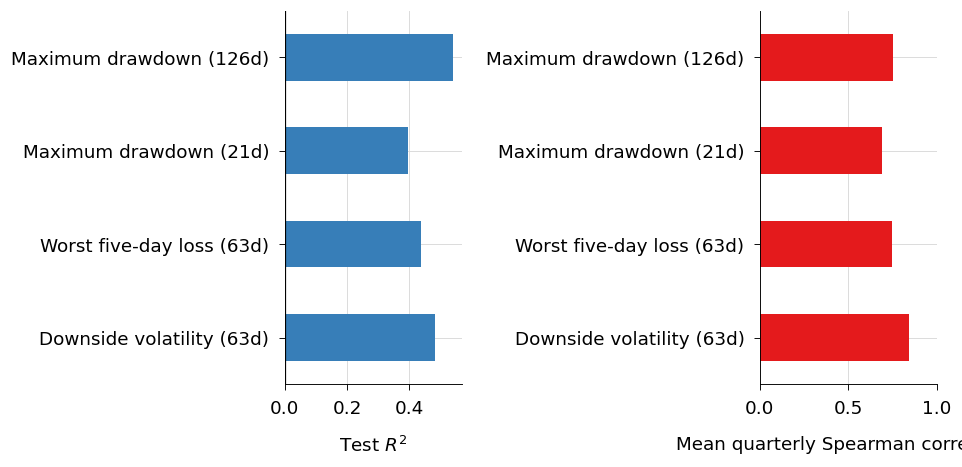

In [5]:
plot_data = summary.set_index("Outcome")
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

plot_data["r2"].plot.barh(ax=axes[0], color=COLOR_PALETTE[0])
axes[0].set(xlabel="Test $R^2$", ylabel="")
axes[0].axvline(0, color="black", linewidth=0.8)

plot_data["mean_quarterly_spearman"].plot.barh(
    ax=axes[1],
    color=COLOR_PALETTE[1],
)
axes[1].set(
    xlabel="Mean quarterly Spearman correlation",
    ylabel="",
)
axes[1].set_xlim(0, 1)

apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "06_01_out_of_sample_performance.pdf")
plt.show()

## 4. Decile monotonicity

Because the outcomes have different scales, each panel shows its own outcome units. A rising line means that higher predicted fragility corresponds to worse realized downside risk.

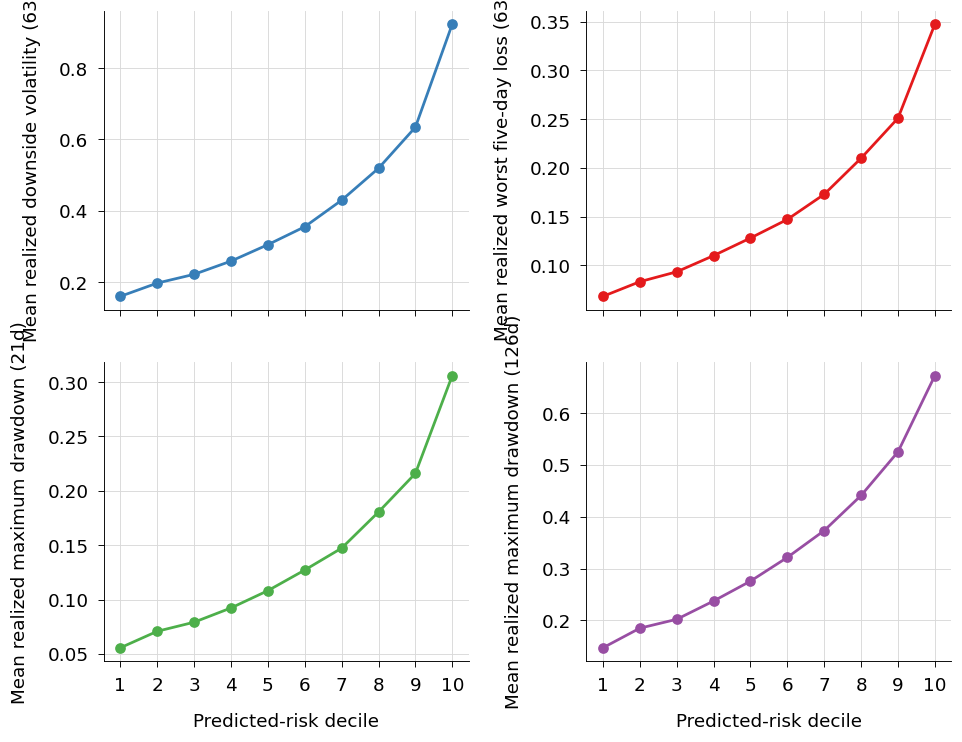

In [6]:
average_deciles = (
    deciles.groupby(["target", "decile"], as_index=False)["mean_actual"].mean()
)
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)

for index, (axis, (target, label)) in enumerate(
    zip(axes.flat, target_labels.items())
):
    values = average_deciles.loc[average_deciles["target"] == target]
    axis.plot(
        values["decile"],
        values["mean_actual"],
        marker="o",
        color=COLOR_PALETTE[index],
    )
    axis.set(ylabel=f"Mean realized {label.lower()}")
    axis.set_xticks(range(1, 11))

axes[1, 0].set_xlabel("Predicted-risk decile")
axes[1, 1].set_xlabel("Predicted-risk decile")
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "06_01_decile_monotonicity.pdf")
plt.show()

## 5. Interpretation

Script 26 creates both alternative horizons for every modeling observation, giving 368,036 target rows. All 184,018 21-day windows are complete and 184,006 are usable. For the 126-day horizon, 180,352 windows are complete and 180,227 are usable; the main reduction comes from the final test quarter, whose forward window is incomplete.

The conclusion is robust to both the definition and horizon of downside risk. Test $R^2$ ranges from 0.395 for 21-day maximum drawdown to 0.538 for 126-day maximum drawdown. Mean within-quarter rank correlations range from 0.691 to 0.839, and realized risk rises monotonically across all ten prediction deciles in every evaluated quarter.

The 126-day test uses seven rather than eight quarters because the last test quarter does not have a complete 126-market-day outcome window. This is the intended no-look-ahead treatment, not missing-model performance.